<a href="https://colab.research.google.com/github/jonitodev/PembelajaranMesin/blob/main/JS04/JS04_SOAL_KUIS1_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [8]:
# Jawab Soal 1

from IPython.display import display

df = df.copy()

# Seragamkan nama kolom: hours-per-week menjadi hours_per_week, dst.
df.columns = df.columns.str.strip().str.lower().str.replace("-", "_", regex=False)

for kolom in df.select_dtypes(include=["object", "string", "category"]).columns:
    df[kolom] = (
        df[kolom].astype("string").str.strip()
        .replace({"?": pd.NA, "": pd.NA})
    )

print("Ukuran dataset:", df.shape)
df.info()
display(df.describe(include="all").T)

missing = df.isna().sum()
ringkasan_missing = pd.DataFrame({
    "jumlah_missing": missing,
    "persentase_missing": (missing / len(df) * 100).round(2)
})

display(ringkasan_missing[ringkasan_missing["jumlah_missing"] > 0])

Ukuran dataset: (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  string
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  string
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  string
 6   occupation      46033 non-null  string
 7   relationship    48842 non-null  string
 8   race            48842 non-null  string
 9   sex             48842 non-null  string
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  47985 non-null  string
 14  income          48842 non-null  string
dtypes: int64(6), string(9)
memory usage: 5.6 MB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital_status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,jumlah_missing,persentase_missing
workclass,2799,5.73
occupation,2809,5.75
native_country,857,1.75


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [9]:
# Jawab Soal 2

for kolom in df.columns[df.isna().any()]:
    if pd.api.types.is_numeric_dtype(df[kolom]):
        pengganti = df[kolom].median()
    else:
        # Modus digunakan untuk fitur kategorikal.
        pengganti = df[kolom].mode().iloc[0]

    df[kolom] = df[kolom].fillna(pengganti)
    print(f"{kolom}: missing value diisi dengan {pengganti}")

display(df.isna().sum().to_frame("jumlah_missing"))
print("Total missing value setelah imputasi:", df.isna().sum().sum())

workclass: missing value diisi dengan Private
occupation: missing value diisi dengan Prof-specialty
native_country: missing value diisi dengan United-States


,jumlah_missing
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


Total missing value setelah imputasi: 0


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [10]:
# Jawab Soal 2

kolom_kategorikal = df.select_dtypes(
    include=["object", "string", "category"]
).columns

print("SEBELUM PENYESUAIAN")
for kolom in kolom_kategorikal:
    print(f"{kolom}: {sorted(df[kolom].dropna().unique().tolist())}")

# Satukan label income yang berbeda karena tanda titik.
df["income"] = df["income"].str.rstrip(".")

# Perbaiki kesalahan penulisan nama negara.
df["native_country"] = df["native_country"].replace({
    "Holand-Netherlands": "Netherlands",
    "Trinadad&Tobago": "Trinidad-and-Tobago",
    "Columbia": "Colombia"
})

print("\nSETELAH PENYESUAIAN")
for kolom in kolom_kategorikal:
    print(f"{kolom}: {sorted(df[kolom].dropna().unique().tolist())}")

SEBELUM PENYESUAIAN
workclass: ['Federal-gov', 'Local-gov', 'Never-worked', 'Private', 'Self-emp-inc', 'Self-emp-not-inc', 'State-gov', 'Without-pay']
education: ['10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th', 'Assoc-acdm', 'Assoc-voc', 'Bachelors', 'Doctorate', 'HS-grad', 'Masters', 'Preschool', 'Prof-school', 'Some-college']
marital_status: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
occupation: ['Adm-clerical', 'Armed-Forces', 'Craft-repair', 'Exec-managerial', 'Farming-fishing', 'Handlers-cleaners', 'Machine-op-inspct', 'Other-service', 'Priv-house-serv', 'Prof-specialty', 'Protective-serv', 'Sales', 'Tech-support', 'Transport-moving']
relationship: ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']
race: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
sex: ['Female', 'Male']
native_country: ['Cambodia', 'Canada', 'China', 'Columbia', 

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

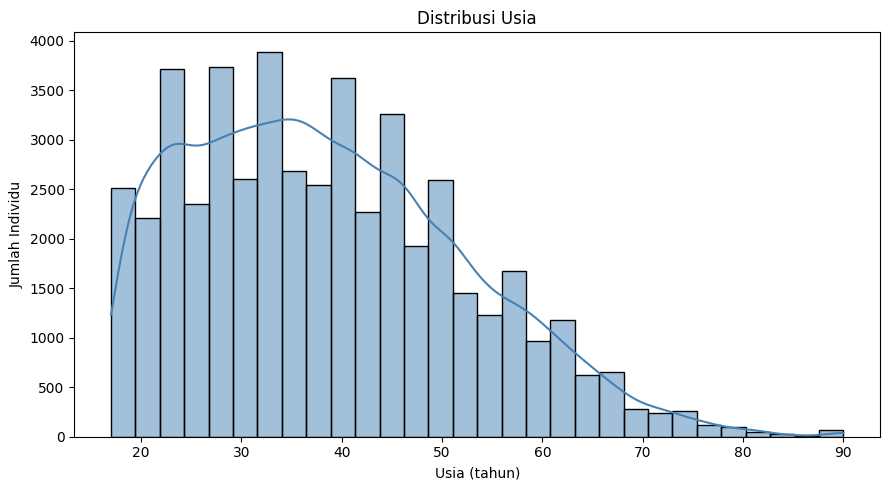

In [12]:
# Jawab 1.1 - Histrogram

plt.figure(figsize=(9, 5))
sns.histplot(data=df, x="age", bins=30, kde=True, color="steelblue")
plt.title("Distribusi Usia")
plt.xlabel("Usia (tahun)")
plt.ylabel("Jumlah Individu")
plt.tight_layout()
plt.show()

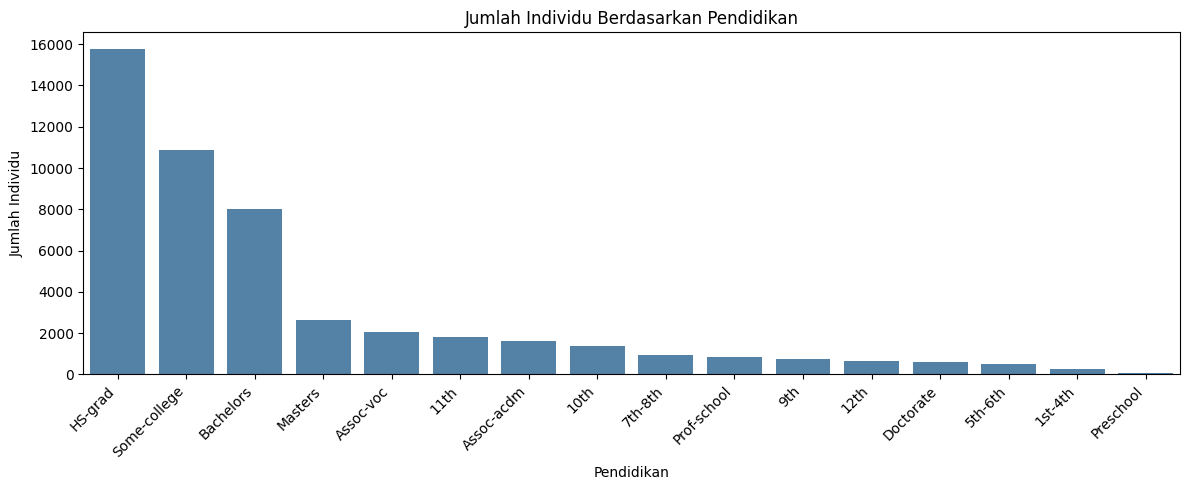

In [13]:
# Jawab 1.2 - Barchart

plt.figure(figsize=(12, 5))
sns.countplot(
    data=df,
    x="education",
    order=df["education"].value_counts().index,
    color="steelblue"
)
plt.title("Jumlah Individu Berdasarkan Pendidikan")
plt.xlabel("Pendidikan")
plt.ylabel("Jumlah Individu")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

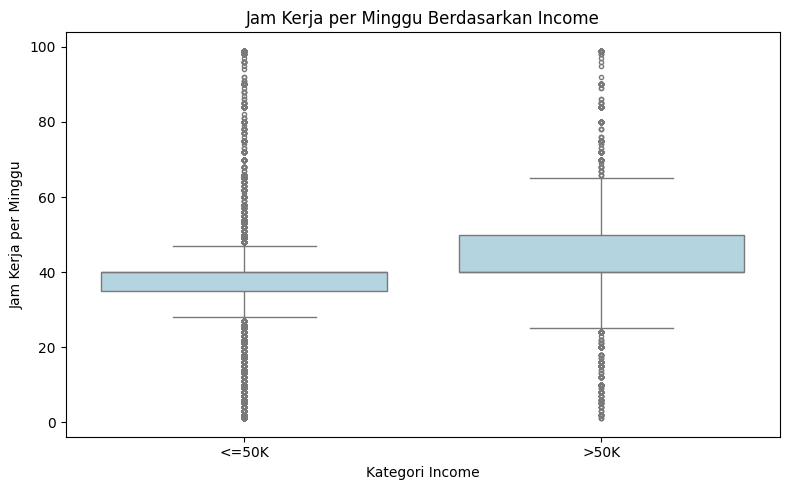

,Q1,Q3,IQR,batas_bawah,batas_atas,jumlah_outlier
income,,,,,,
<=50K,35.0,40.0,5.0,27.5,47.5,11706
>50K,40.0,50.0,10.0,25.0,65.0,781


In [14]:
# Jawab 1.3 - Boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="income",
    y="hours_per_week",
    order=["<=50K", ">50K"],
    whis=1.5,
    color="lightblue",
    flierprops={"markersize": 3}
)
plt.title("Jam Kerja per Minggu Berdasarkan Income")
plt.xlabel("Kategori Income")
plt.ylabel("Jam Kerja per Minggu")
plt.tight_layout()
plt.show()

# Hitung jumlah observasi outlier dengan aturan yang sama seperti boxplot.
hasil_outlier = []

for kategori, kelompok in df.groupby("income"):
    jam = kelompok["hours_per_week"]
    q1, q3 = jam.quantile([0.25, 0.75])
    iqr = q3 - q1

    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    jumlah_outlier = ((jam < batas_bawah) | (jam > batas_atas)).sum()

    hasil_outlier.append({
        "income": kategori,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "batas_bawah": batas_bawah,
        "batas_atas": batas_atas,
        "jumlah_outlier": int(jumlah_outlier)
    })

outlier_income = pd.DataFrame(hasil_outlier).set_index("income")
display(outlier_income)

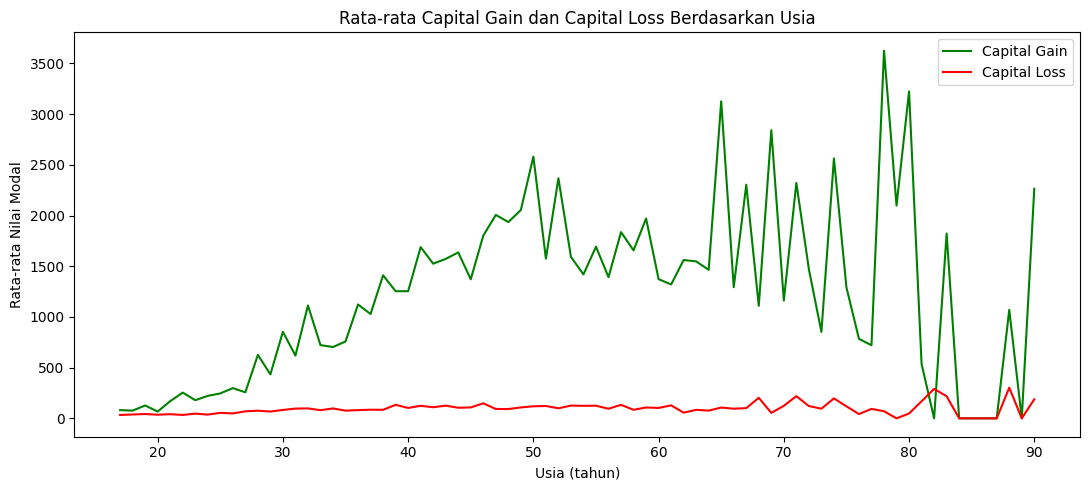

In [15]:
# Jawab 1.4 - Lineplot

# Gunakan rata-rata karena terdapat banyak individu dengan usia yang sama.
rata_rata_modal = (
    df.groupby("age")[["capital_gain", "capital_loss"]]
    .mean()
    .reset_index()
)

plt.figure(figsize=(11, 5))
sns.lineplot(
    data=rata_rata_modal, x="age", y="capital_gain",
    label="Capital Gain", color="green"
)
sns.lineplot(
    data=rata_rata_modal, x="age", y="capital_loss",
    label="Capital Loss", color="red"
)
plt.title("Rata-rata Capital Gain dan Capital Loss Berdasarkan Usia")
plt.xlabel("Usia (tahun)")
plt.ylabel("Rata-rata Nilai Modal")
plt.legend()
plt.tight_layout()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:
# Jawab dengan komentar python

'''
1. Distribusi age cenderung miring ke kanan (positive skew).
   Data terkonsentrasi pada usia dewasa muda hingga paruh baya.
   Individu berusia lanjut lebih sedikit sehingga membentuk ekor ke kanan.
   Rata-rata usia sekitar 38,64 tahun, sedangkan mediannya 37 tahun.

2. Jika age memiliki missing value, gunakan imputasi median.
   Median lebih tahan terhadap nilai ekstrem dibandingkan mean sehingga
   sesuai untuk distribusi usia yang tidak simetris.
   Median dihitung dari nilai age yang tersedia.

3. Outlier dihitung menggunakan batas Q1 - 1,5 × IQR dan Q3 + 1,5 × IQR
   secara terpisah untuk setiap kategori income.

   Income <=50K:
   - Q1 = 35, Q3 = 40, IQR = 5.
   - Batas bawah = 27,5 dan batas atas = 47,5.
   - Jumlah outlier = 11.706 observasi.

   Income >50K:
   - Q1 = 40, Q3 = 50, IQR = 10.
   - Batas bawah = 25 dan batas atas = 65.
   - Jumlah outlier = 781 observasi.

   Kategori <=50K memiliki jumlah outlier paling banyak.
   Jumlah tersebut menghitung observasi, termasuk titik yang bertumpuk
   pada boxplot. Outlier secara statistik belum tentu merupakan data salah.
'''

'\n  Bisa dengan multiple comment\n  seperti ini\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [29]:
# Jawab Soal 1

sex_asli = adult_income.data.features["sex"].astype("string").str.strip()

income_asli = (
    adult_income.data.targets["income"]
    .astype("string").str.strip().str.rstrip(".")
)

df["sex"] = sex_asli.map({
    "Female": 0,
    "Male": 1
}).astype(int)

df["income"] = income_asli.map({
    "<=50K": 0,
    ">50K": 1
}).astype(int)

display(df[["sex", "income"]].head())
display(df["income"].value_counts().sort_index().to_frame("jumlah"))

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


,jumlah
income,
0,37155
1,11687


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

,age,education_num,hours_per_week,capital_gain,capital_loss,income
age,1.000,0.031,0.072,0.077,0.057,NaN
education_num,0.031,1.000,0.144,0.125,0.081,NaN
hours_per_week,0.072,0.144,1.000,0.082,0.054,NaN
capital_gain,0.077,0.125,0.082,1.000,-0.031,NaN
capital_loss,0.057,0.081,0.054,-0.031,1.000,NaN
income,NaN,NaN,NaN,NaN,NaN,NaN


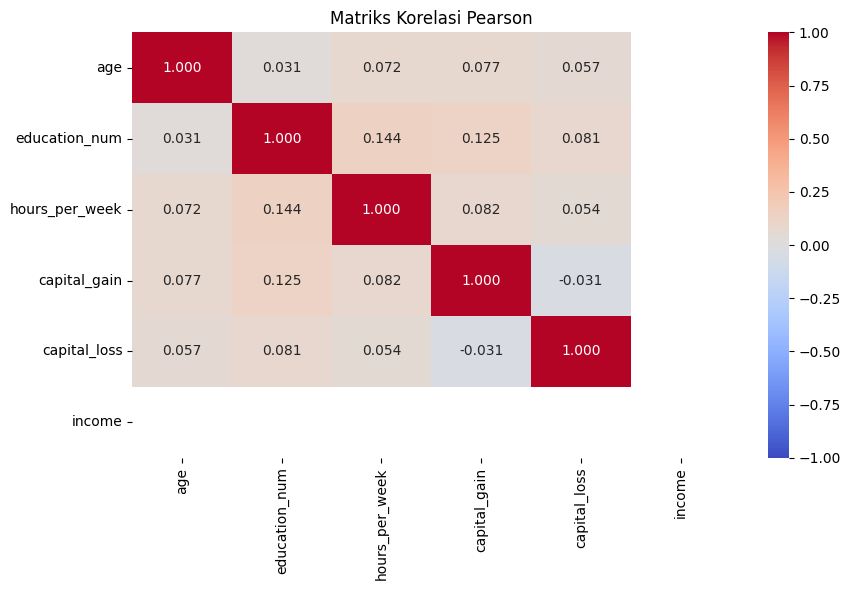

In [23]:
# Jawab Soal 1

kolom_korelasi = [
    "age",
    "education_num",
    "hours_per_week",
    "capital_gain",
    "capital_loss",
    "income"
]

korelasi = df[kolom_korelasi].corr(method="pearson")
display(korelasi.round(3))

plt.figure(figsize=(9, 6))
sns.heatmap(
    korelasi,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Matriks Korelasi Pearson")
plt.tight_layout()
plt.show()

In [ ]:
# Hasil analisis jelaskan pada cell ini

'''
Income di-encoding sebagai 0 untuk <=50K dan 1 untuk >50K.

1. education_num memiliki korelasi positif terbesar terhadap income
   di antara fitur yang dianalisis, yaitu sekitar 0,333.
   Tingkat pendidikan yang lebih tinggi cenderung berkaitan dengan
   kategori income >50K, tetapi hubungan linearnya tidak kuat.

2. age (0,230), hours_per_week (0,228), dan capital_gain (0,223)
   memiliki korelasi positif yang relatif lemah terhadap income.

3. capital_loss memiliki korelasi positif paling kecil terhadap income,
   yaitu sekitar 0,148.

4. Korelasi antarfitur prediktor relatif lemah; nilai absolut tertingginya
   sekitar 0,144, antara education_num dan hours_per_week.

5. Korelasi menunjukkan hubungan statistik, bukan hubungan sebab-akibat.
'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [24]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


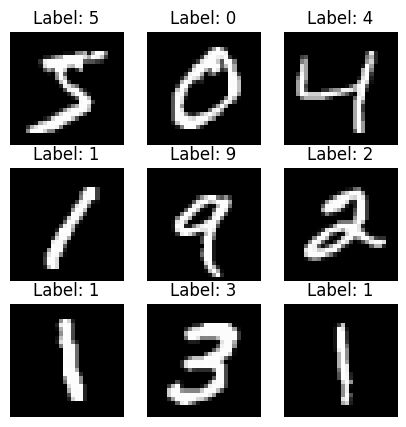

In [25]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Shape sebelum upsampling: (10000, 28, 28)
Shape setelah upsampling: (10000, 32, 32)


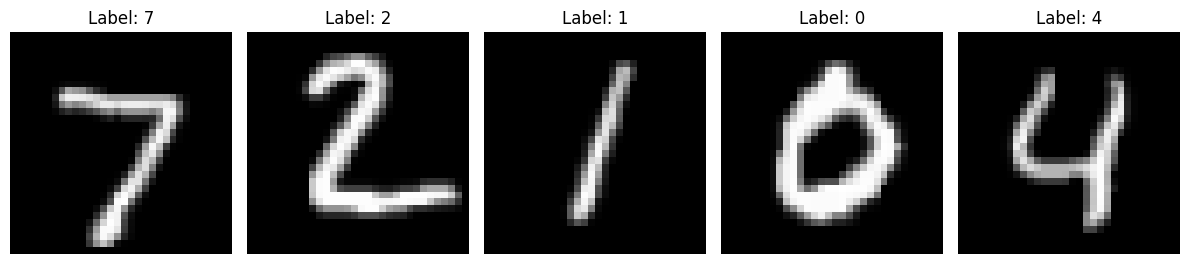

In [26]:
# Jawab Soal 1

from PIL import Image

# Holder baru karena ukuran citra berubah dari 28 × 28 menjadi 32 × 32.
X_test_resized = np.empty((len(X_test), 32, 32), dtype=np.uint8)

for i, citra in enumerate(X_test):
    X_test_resized[i] = np.asarray(
        Image.fromarray(citra).resize(
            (32, 32),
            resample=Image.Resampling.BILINEAR
        )
    )

print("Shape sebelum upsampling:", X_test.shape)
print("Shape setelah upsampling:", X_test_resized.shape)

fig, axes = plt.subplots(1, 5, figsize=(12, 3))

for i, ax in enumerate(axes):
    ax.imshow(X_test_resized[i], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"Label: {y_test[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [27]:
# Jawab Soal 2

X_test_normalized = X_test_resized.astype(np.float32) / 255.0

print("Shape:", X_test_normalized.shape)
print("Tipe data:", X_test_normalized.dtype)
print("Nilai piksel minimum:", X_test_normalized.min())
print("Nilai piksel maksimum:", X_test_normalized.max())

Shape: (10000, 32, 32)
Tipe data: float32
Nilai piksel minimum: 0.0
Nilai piksel maksimum: 1.0


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [28]:
# Jawab Soal 3

jumlah_data, tinggi, lebar = X_test_normalized.shape

# Setiap citra 32 × 32 menjadi satu vektor berisi 1.024 nilai.
X_test_flattened = np.empty(
    (jumlah_data, tinggi * lebar),
    dtype=np.float32
)

for i, citra in enumerate(X_test_normalized):
    X_test_flattened[i] = citra.flatten()

print("Shape sebelum flatten:", X_test_normalized.shape)
print("Shape setelah flatten:", X_test_flattened.shape)
print("Shape satu citra:", X_test_flattened[0].shape)
print("Tipe data:", X_test_flattened.dtype)

Shape sebelum flatten: (10000, 32, 32)
Shape setelah flatten: (10000, 1024)
Shape satu citra: (1024,)
Tipe data: float32
